### Ejercicio - 1



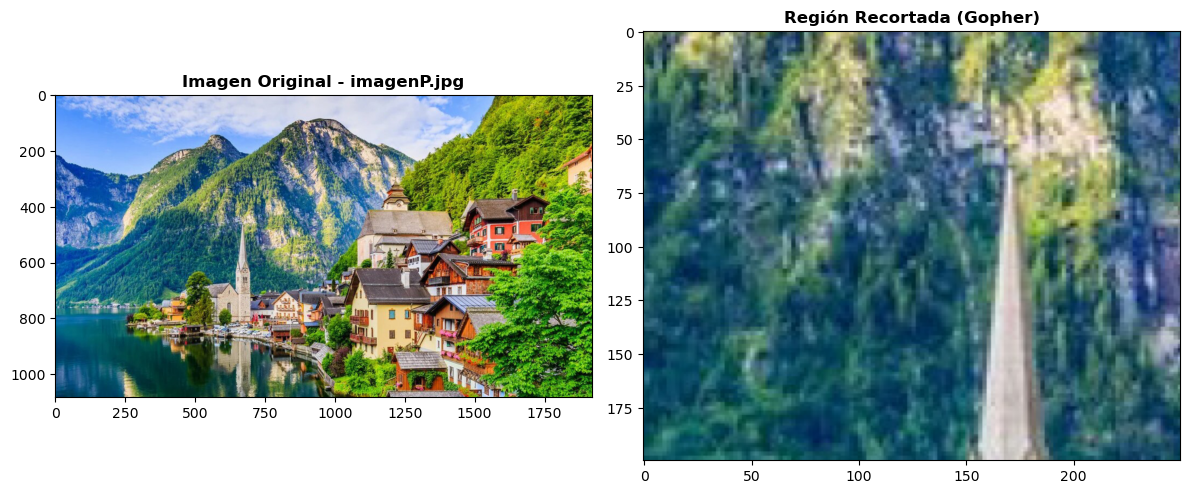

Imagen original: (1080, 1920, 3)
Imagen recortada: (200, 250, 3)
Imagen recortada guardada como 'imagenP_recortada.jpg'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2


imagen = cv2.imread('imagenP.jpg.jpeg')
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)


roi = imagen_rgb[400:600, 500:750]


cv2.imwrite('imagenP_recortada.jpg', cv2.cvtColor(roi, cv2.COLOR_RGB2BGR))


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(imagen_rgb)
axes[0].set_title('Imagen Original - imagenP.jpg', fontsize=12, fontweight='bold')

axes[1].imshow(roi)
axes[1].set_title('Región Recortada (Gopher)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Imagen original: {imagen.shape}")
print(f"Imagen recortada: {roi.shape}")
print("Imagen recortada guardada como 'imagenP_recortada.jpg'")

### Ejercicio - 2


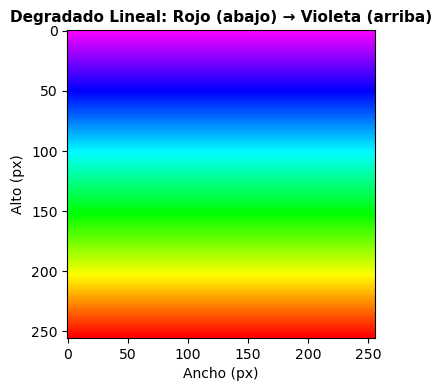

Imagen generada: (256, 256, 3)
Guardada como 'degradado_colores.png'


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

alto, ancho = 256, 256


hsv = np.zeros((alto, ancho, 3), dtype=np.uint8)

for y in range(alto):

    hue = int(150 * (1 - y / (alto - 1)))
    hsv[y, :, 0] = hue       
    hsv[y, :, 1] = 255       
    hsv[y, :, 2] = 255       


degradado_bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
degradado_rgb = cv2.cvtColor(degradado_bgr, cv2.COLOR_BGR2RGB)


cv2.imwrite('degradado_colores.png', degradado_bgr)


plt.figure(figsize=(4, 6))
plt.imshow(degradado_rgb)
plt.title('Degradado Lineal: Rojo (abajo) → Violeta (arriba)', fontsize=11, fontweight='bold')
plt.xlabel('Ancho (px)')
plt.ylabel('Alto (px)')
plt.tight_layout()
plt.show()

print(f"Imagen generada: {degradado_bgr.shape}")
print("Guardada como 'degradado_colores.png'")

### Ejercicio 3


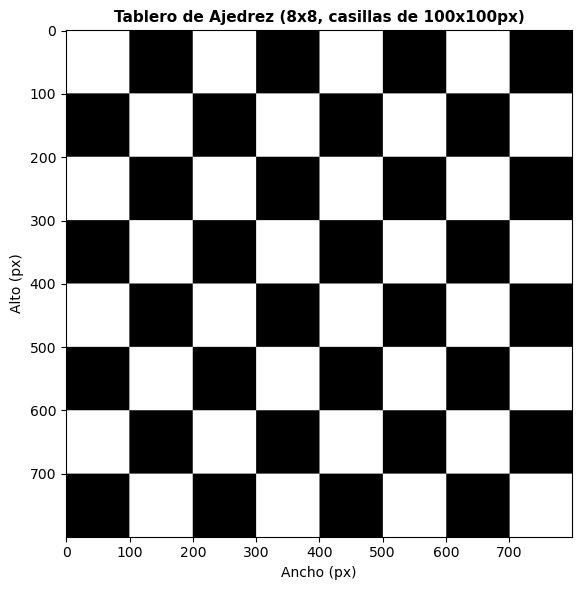

Tablero generado: (800, 800)
Guardado como 'tablero_ajedrez.png'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

casilla = 100  
n_casillas = 8  
tam = casilla * n_casillas 


tablero = np.zeros((tam, tam), dtype=np.uint8)

for fila in range(n_casillas):
    for col in range(n_casillas):
        if (fila + col) % 2 == 0:
            y1, y2 = fila * casilla, (fila + 1) * casilla
            x1, x2 = col * casilla, (col + 1) * casilla
            tablero[y1:y2, x1:x2] = 255


cv2.imwrite('tablero_ajedrez.png', tablero)


plt.figure(figsize=(6, 6))
plt.imshow(tablero, cmap='gray', vmin=0, vmax=255)
plt.title(f'Tablero de Ajedrez ({n_casillas}x{n_casillas}, casillas de {casilla}x{casilla}px)',
          fontsize=11, fontweight='bold')
plt.xlabel('Ancho (px)')
plt.ylabel('Alto (px)')
plt.tight_layout()
plt.show()

print(f"Tablero generado: {tablero.shape}")
print("Guardado como 'tablero_ajedrez.png'")

### Ejercicio - 4


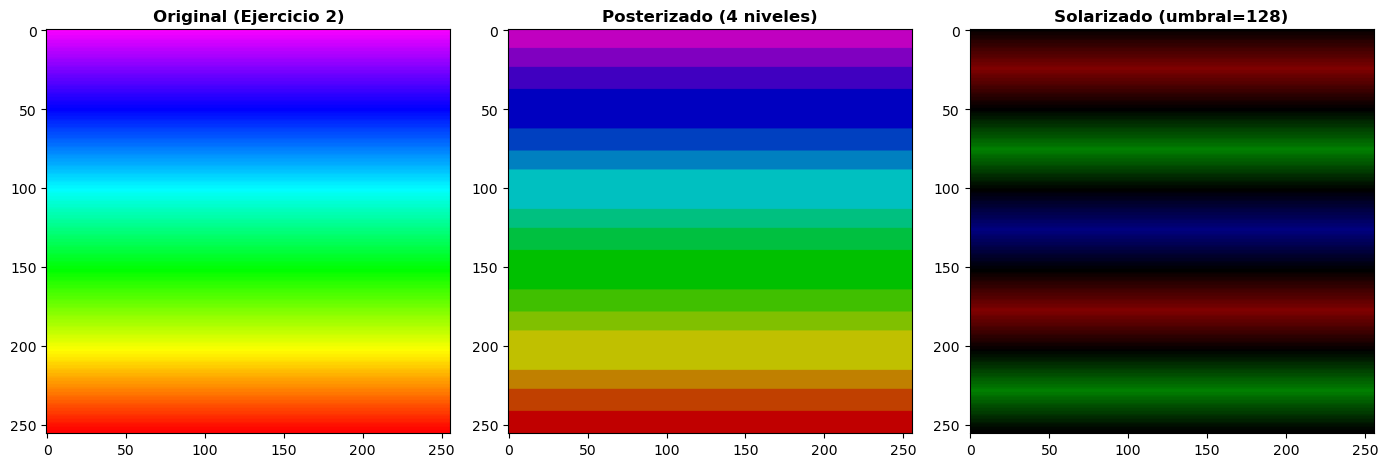

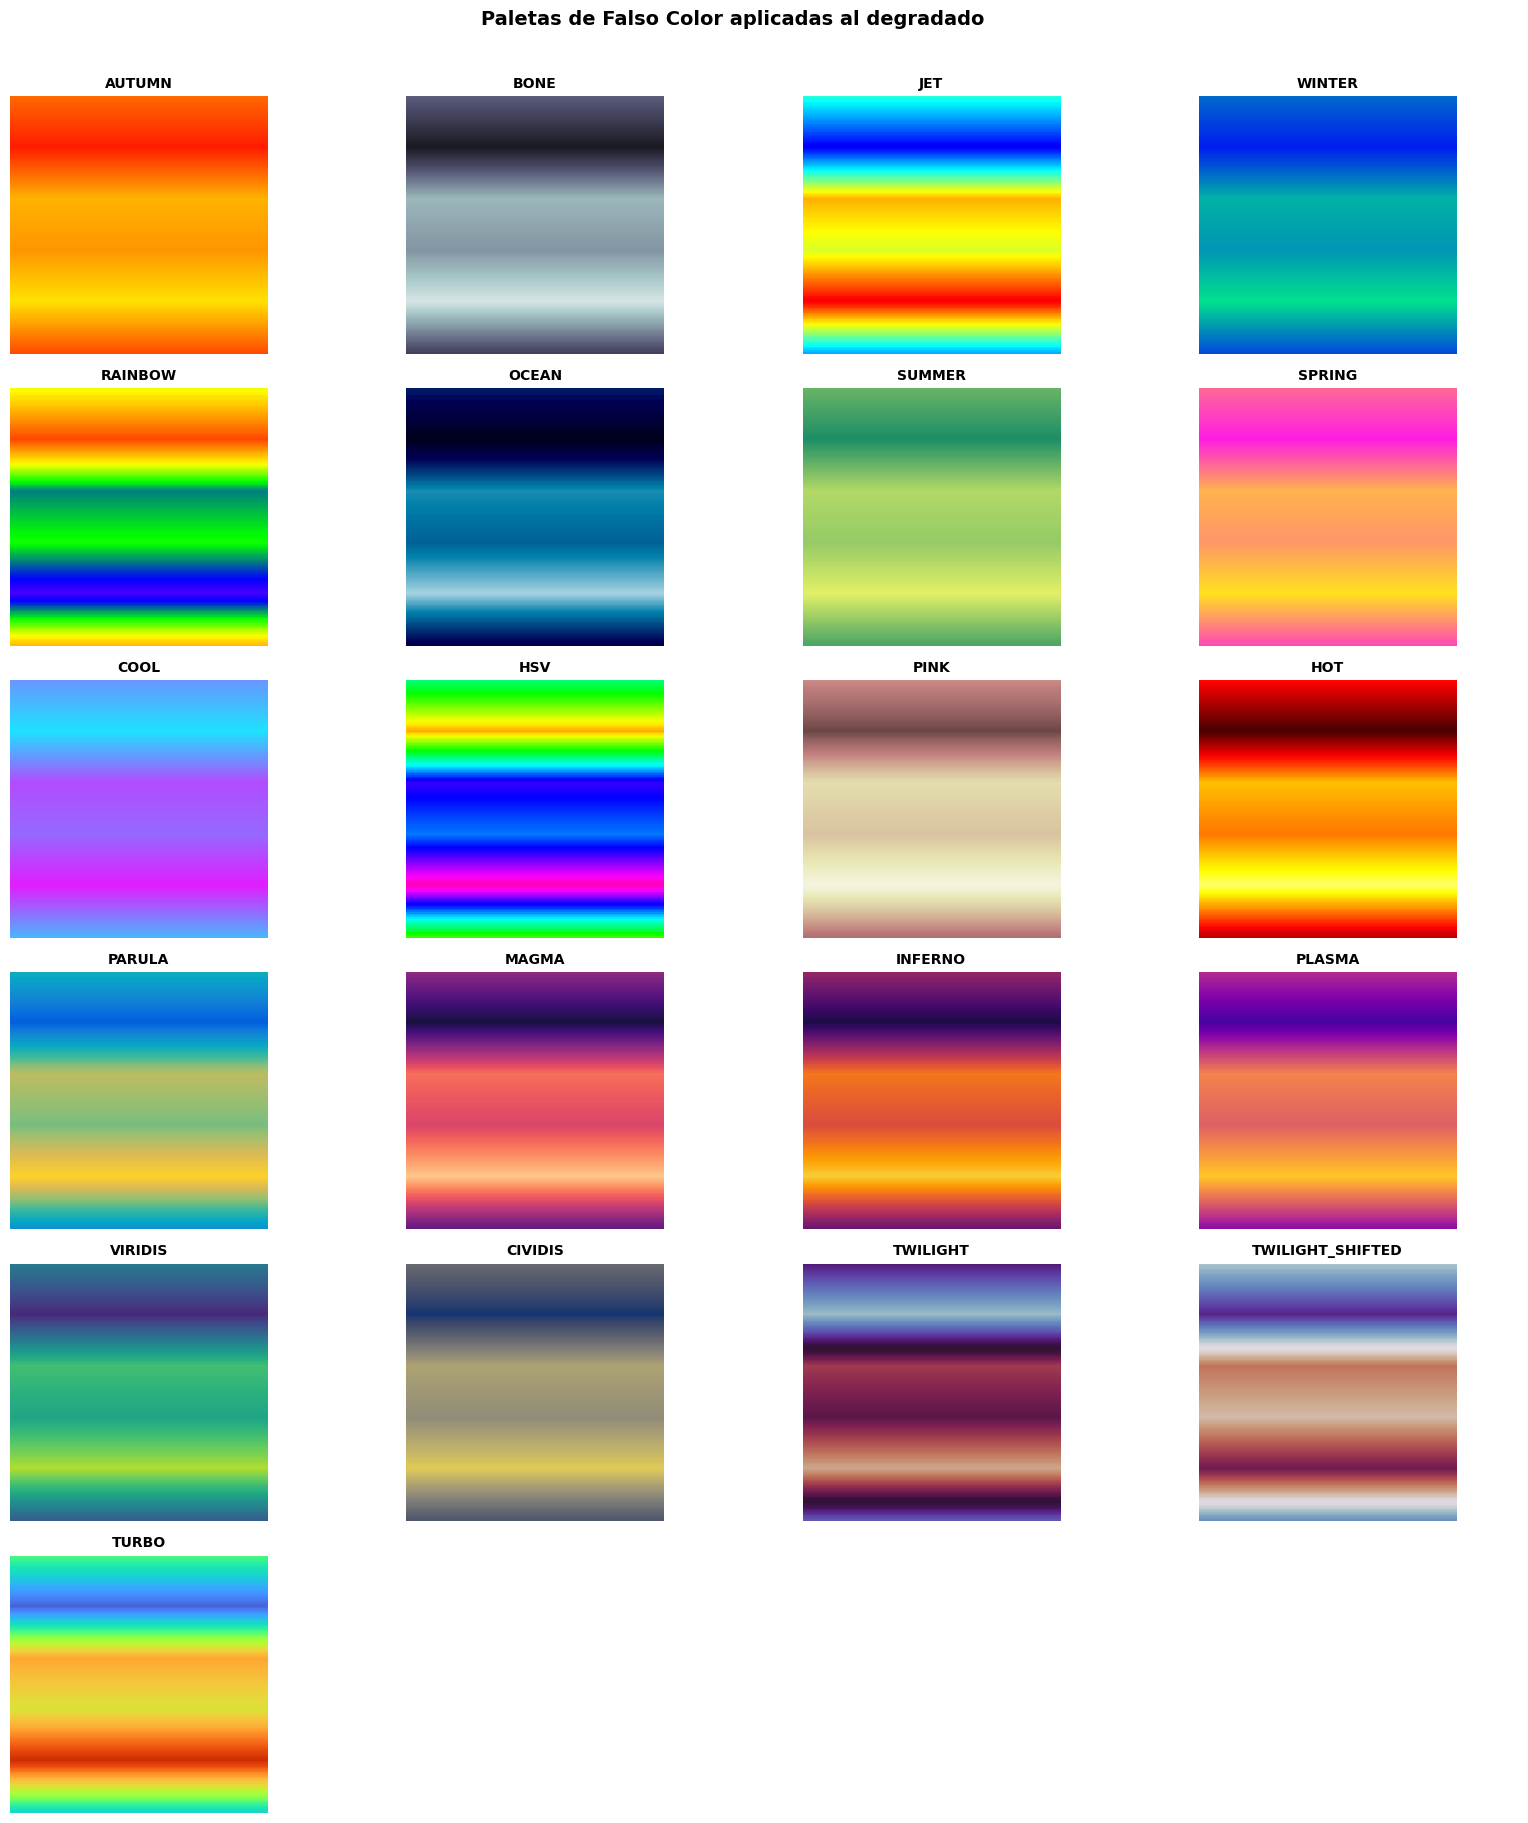

Total de imágenes guardadas: 23 (posterizado + solarizado + 21 paletas)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2


degradado = cv2.imread('degradado_colores.png')
degradado_rgb = cv2.cvtColor(degradado, cv2.COLOR_BGR2RGB)

niveles = 4
factor = 256 // niveles
posterizado = (degradado // factor) * factor
posterizado_rgb = cv2.cvtColor(posterizado, cv2.COLOR_BGR2RGB)
cv2.imwrite('ej4_posterizado.png', posterizado)

umbral = 128
solarizado = degradado.copy()
solarizado[solarizado > umbral] = 255 - solarizado[solarizado > umbral]
solarizado_rgb = cv2.cvtColor(solarizado, cv2.COLOR_BGR2RGB)
cv2.imwrite('ej4_solarizado.png', solarizado)


fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(degradado_rgb)
axes[0].set_title('Original (Ejercicio 2)', fontweight='bold')
axes[1].imshow(posterizado_rgb)
axes[1].set_title(f'Posterizado ({niveles} niveles)', fontweight='bold')
axes[2].imshow(solarizado_rgb)
axes[2].set_title(f'Solarizado (umbral={umbral})', fontweight='bold')
plt.tight_layout()
plt.show()

degradado_gris = cv2.cvtColor(degradado, cv2.COLOR_BGR2GRAY)

# paletas de falso color de OpenCV
colormaps = {
    'AUTUMN': cv2.COLORMAP_AUTUMN,
    'BONE': cv2.COLORMAP_BONE,
    'JET': cv2.COLORMAP_JET,
    'WINTER': cv2.COLORMAP_WINTER,
    'RAINBOW': cv2.COLORMAP_RAINBOW,
    'OCEAN': cv2.COLORMAP_OCEAN,
    'SUMMER': cv2.COLORMAP_SUMMER,
    'SPRING': cv2.COLORMAP_SPRING,
    'COOL': cv2.COLORMAP_COOL,
    'HSV': cv2.COLORMAP_HSV,
    'PINK': cv2.COLORMAP_PINK,
    'HOT': cv2.COLORMAP_HOT,
    'PARULA': cv2.COLORMAP_PARULA,
    'MAGMA': cv2.COLORMAP_MAGMA,
    'INFERNO': cv2.COLORMAP_INFERNO,
    'PLASMA': cv2.COLORMAP_PLASMA,
    'VIRIDIS': cv2.COLORMAP_VIRIDIS,
    'CIVIDIS': cv2.COLORMAP_CIVIDIS,
    'TWILIGHT': cv2.COLORMAP_TWILIGHT,
    'TWILIGHT_SHIFTED': cv2.COLORMAP_TWILIGHT_SHIFTED,
    'TURBO': cv2.COLORMAP_TURBO,
}

n_maps = len(colormaps)
cols = 4
filas = (n_maps + cols - 1) // cols

fig, axes = plt.subplots(filas, cols, figsize=(16, filas * 3))
axes = axes.flatten()

for i, (nombre, cmap) in enumerate(colormaps.items()):
    falso_color = cv2.applyColorMap(degradado_gris, cmap)
    falso_color_rgb = cv2.cvtColor(falso_color, cv2.COLOR_BGR2RGB)
    
   
    cv2.imwrite(f'ej4_falsocolor_{nombre.lower()}.png', falso_color)
    
    axes[i].imshow(falso_color_rgb)
    axes[i].set_title(nombre, fontweight='bold', fontsize=10)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Paletas de Falso Color aplicadas al degradado', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Total de imágenes guardadas: {n_maps + 2} (posterizado + solarizado + {n_maps} paletas)")

### Ejercicio 5


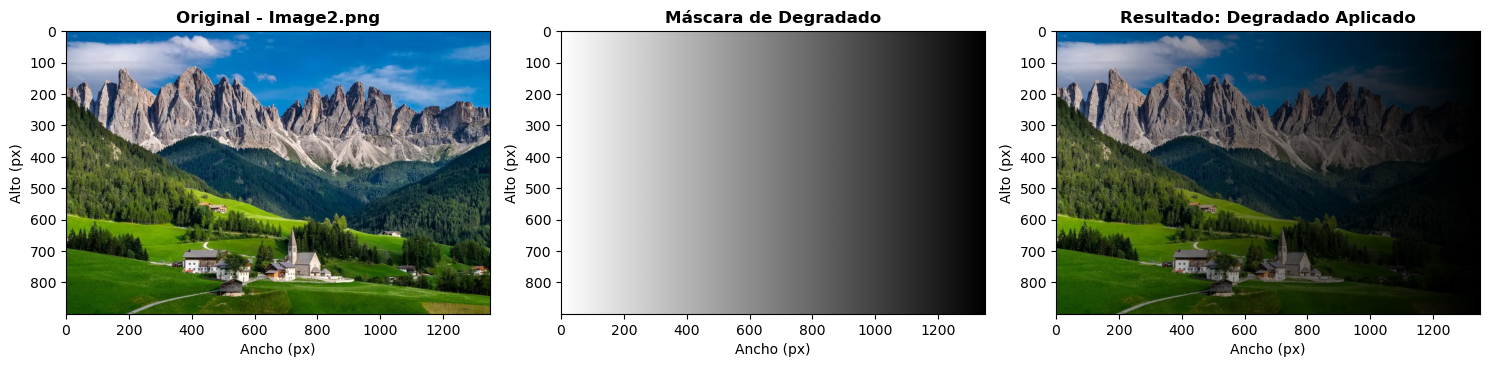

Imagen con degradado: (900, 1350, 3)
Guardada como 'ej5_degradado_lineal.png'


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

imagen = cv2.imread('Imagen1.jpg')
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
alto, ancho = imagen.shape[:2]

gradiente = np.linspace(1.0, 0.0, ancho).reshape(1, ancho)

mascara = np.repeat(gradiente, alto, axis=0)

mascara_3ch = np.stack([mascara] * 3, axis=2)


resultado = (imagen_rgb.astype(np.float64) * mascara_3ch).astype(np.uint8)


cv2.imwrite('ej5_degradado_lineal.png', cv2.cvtColor(resultado, cv2.COLOR_RGB2BGR))


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(imagen_rgb)
axes[0].set_title('Original - Image2.png', fontweight='bold')

axes[1].imshow(mascara, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Máscara de Degradado', fontweight='bold')

axes[2].imshow(resultado)
axes[2].set_title('Resultado: Degradado Aplicado', fontweight='bold')

for ax in axes:
    ax.set_xlabel('Ancho (px)')
    ax.set_ylabel('Alto (px)')

plt.tight_layout()
plt.show()

print(f"Imagen con degradado: {resultado.shape}")
print("Guardada como 'ej5_degradado_lineal.png'")

### Ejercicio - 6


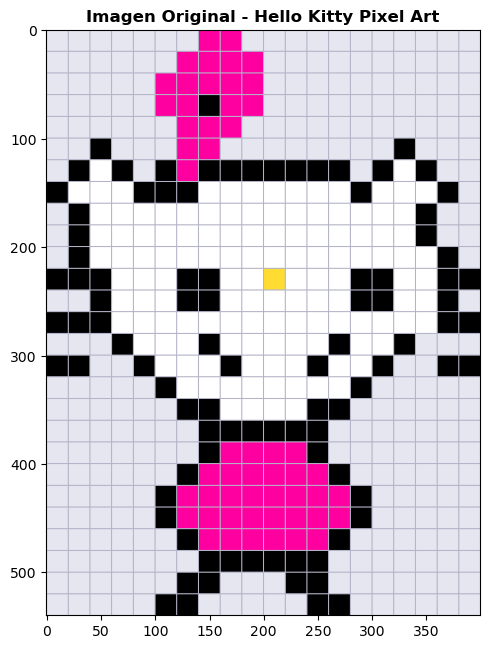

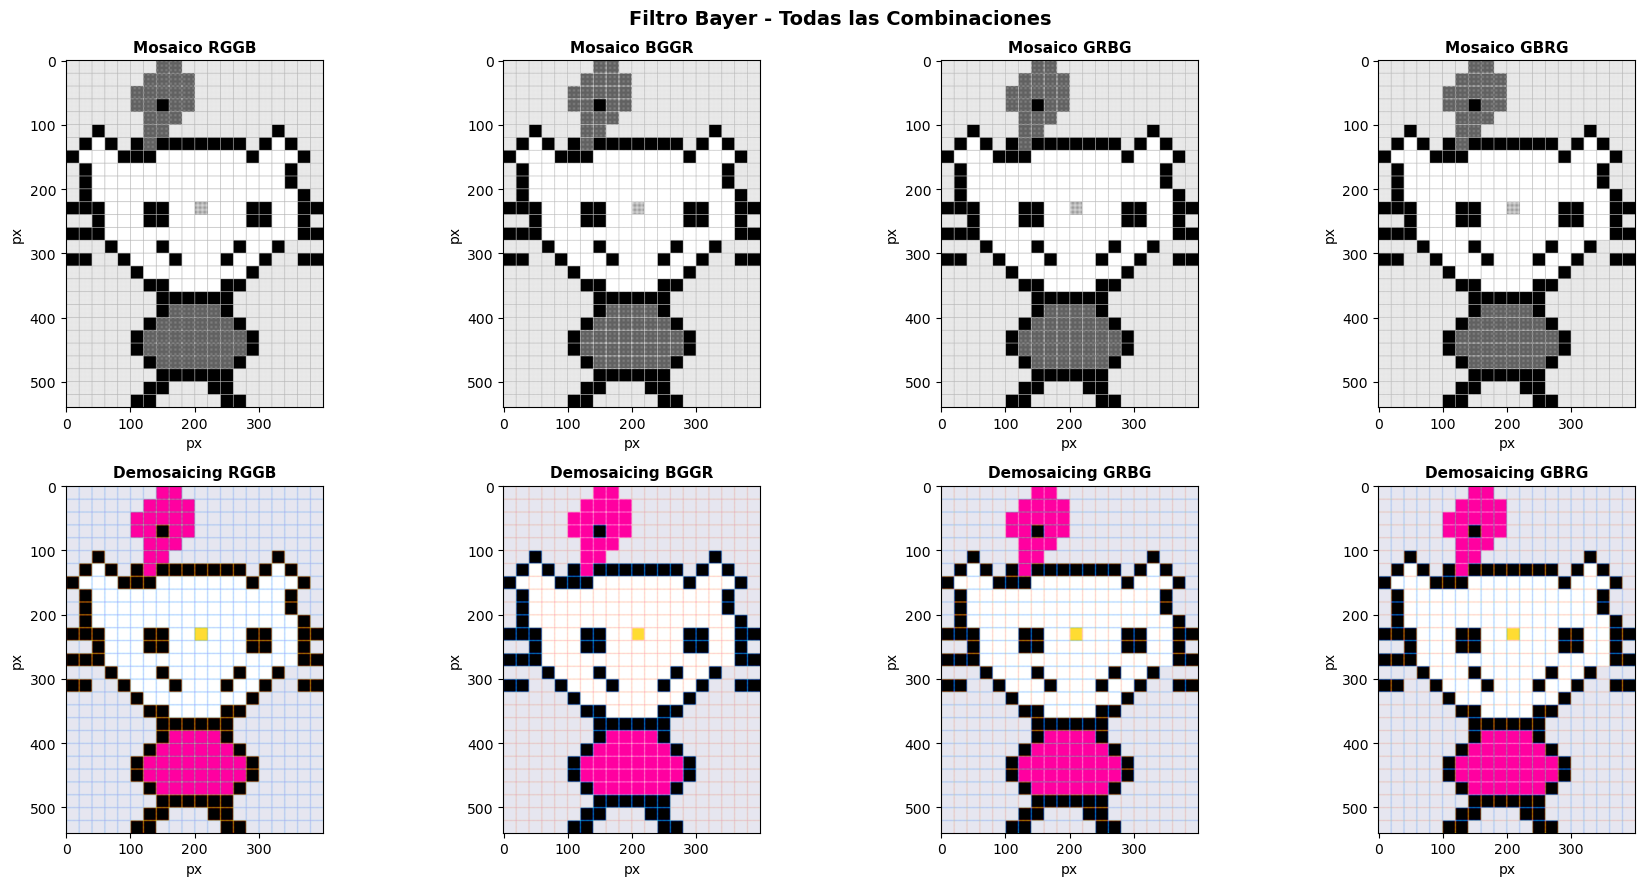

Imágenes guardadas: imagen original + 4 mosaicos + 4 reconstrucciones


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# === Hello Kitty Pixel Art ===
# Colores: 0=fondo, 1=negro, 2=blanco, 3=rosa/magenta, 4=amarillo

paleta = {
    0: (230, 230, 240),   # fondo (gris claro / grid)
    1: (0, 0, 0),         # negro (contorno)
    2: (255, 255, 255),   # blanco (cuerpo)
    3: (255, 0, 160),     # rosa/magenta (lazo y vestido)
    4: (255, 220, 50),    # amarillo (nariz)
}

# Mapa de píxeles 20 col × 27 filas
# Con orejas de gato, lazo, bigotes, vestido y pies
hk = np.array([
    # Lazo (arriba)
    [0,0,0,0,0,0,0,3,3,0,0,0,0,0,0,0,0,0,0,0],  # 0
    [0,0,0,0,0,0,3,3,3,3,0,0,0,0,0,0,0,0,0,0],  # 1
    [0,0,0,0,0,3,3,3,3,3,0,0,0,0,0,0,0,0,0,0],  # 2
    [0,0,0,0,0,3,3,1,3,3,0,0,0,0,0,0,0,0,0,0],  # 3 nudo del lazo
    [0,0,0,0,0,0,3,3,3,0,0,0,0,0,0,0,0,0,0,0],  # 4 base lazo
    # Orejas + cabeza
    [0,0,1,0,0,0,3,3,0,0,0,0,0,0,0,0,1,0,0,0],  # 5 puntas orejas
    [0,1,2,1,0,1,3,1,1,1,1,1,1,1,0,1,2,1,0,0],  # 6 lados orejas
    [1,2,2,2,1,1,1,2,2,2,2,2,2,2,1,2,2,2,1,0],  # 7 orejas + cabeza
    [0,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,1,0,0],  # 8 cabeza
    [0,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,1,0,0],  # 9
    [0,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,1,0],  # 10
    # Ojos + nariz + bigotes
    [1,1,1,2,2,2,1,1,2,2,4,2,2,2,1,1,2,2,1,1],  # 11 ojos+nariz+bigotes
    [0,0,1,2,2,2,1,1,2,2,2,2,2,2,1,1,2,2,1,0],  # 12 ojos
    [1,1,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,1,1],  # 13 bigotes
    # Boca
    [0,0,0,1,2,2,2,1,2,2,2,2,2,1,2,2,1,0,0,0],  # 14 boca
    [1,1,0,0,1,2,2,2,1,2,2,2,1,2,2,1,0,0,1,1],  # 15 bigotes
    [0,0,0,0,0,1,2,2,2,2,2,2,2,2,1,0,0,0,0,0],  # 16
    [0,0,0,0,0,0,1,1,2,2,2,2,1,1,0,0,0,0,0,0],  # 17
    [0,0,0,0,0,0,0,1,1,1,1,1,1,0,0,0,0,0,0,0],  # 18 barbilla
    # Vestido
    [0,0,0,0,0,0,0,1,3,3,3,3,1,0,0,0,0,0,0,0],  # 19
    [0,0,0,0,0,0,1,3,3,3,3,3,3,1,0,0,0,0,0,0],  # 20
    [0,0,0,0,0,1,3,3,3,3,3,3,3,3,1,0,0,0,0,0],  # 21
    [0,0,0,0,0,1,3,3,3,3,3,3,3,3,1,0,0,0,0,0],  # 22
    [0,0,0,0,0,0,1,3,3,3,3,3,3,1,0,0,0,0,0,0],  # 23
    [0,0,0,0,0,0,0,1,1,1,1,1,1,0,0,0,0,0,0,0],  # 24
    # Pies
    [0,0,0,0,0,0,1,1,0,0,0,1,1,0,0,0,0,0,0,0],  # 25
    [0,0,0,0,0,1,1,0,0,0,0,0,1,1,0,0,0,0,0,0],  # 26
], dtype=np.uint8)

# Escalar cada píxel a un bloque más grande
escala = 20
alto_px, ancho_px = hk.shape
tam_alto = alto_px * escala
tam_ancho = ancho_px * escala

# Crear imagen RGB
imagen_arte = np.zeros((tam_alto, tam_ancho, 3), dtype=np.uint8)

for y in range(alto_px):
    for x in range(ancho_px):
        color = paleta[hk[y, x]]
        y1, y2 = y * escala, (y + 1) * escala
        x1, x2 = x * escala, (x + 1) * escala
        imagen_arte[y1:y2, x1:x2] = color

# Dibujar líneas de cuadrícula
for y in range(0, tam_alto, escala):
    imagen_arte[y, :] = (180, 180, 200)
for x in range(0, tam_ancho, escala):
    imagen_arte[:, x] = (180, 180, 200)

# Guardar imagen original
imagen_arte_bgr = cv2.cvtColor(imagen_arte, cv2.COLOR_RGB2BGR)
cv2.imwrite('ej6_imagen_hellokitty.png', imagen_arte_bgr)

# Mostrar imagen original
plt.figure(figsize=(5, 7))
plt.imshow(imagen_arte)
plt.title('Imagen Original - Hello Kitty Pixel Art', fontweight='bold', fontsize=12)
plt.axis('on')
plt.tight_layout()
plt.show()

# === Filtro Bayer ===
alto, ancho = imagen_arte.shape[:2]
R = imagen_arte[:, :, 0]
G = imagen_arte[:, :, 1]
B = imagen_arte[:, :, 2]


def aplicar_bayer(img_rgb, patron):
    """Simula el mosaico Bayer sobre una imagen RGB"""
    alto, ancho = img_rgb.shape[:2]
    R, G, B = img_rgb[:, :, 0], img_rgb[:, :, 1], img_rgb[:, :, 2]
    bayer = np.zeros((alto, ancho), dtype=np.uint8)
    
    y_par = np.arange(0, alto, 2)
    y_impar = np.arange(1, alto, 2)
    x_par = np.arange(0, ancho, 2)
    x_impar = np.arange(1, ancho, 2)
    
    if patron == 'RGGB':
        bayer[np.ix_(y_par, x_par)] = R[np.ix_(y_par, x_par)]
        bayer[np.ix_(y_par, x_impar)] = G[np.ix_(y_par, x_impar)]
        bayer[np.ix_(y_impar, x_par)] = G[np.ix_(y_impar, x_par)]
        bayer[np.ix_(y_impar, x_impar)] = B[np.ix_(y_impar, x_impar)]
    elif patron == 'BGGR':
        bayer[np.ix_(y_par, x_par)] = B[np.ix_(y_par, x_par)]
        bayer[np.ix_(y_par, x_impar)] = G[np.ix_(y_par, x_impar)]
        bayer[np.ix_(y_impar, x_par)] = G[np.ix_(y_impar, x_par)]
        bayer[np.ix_(y_impar, x_impar)] = R[np.ix_(y_impar, x_impar)]
    elif patron == 'GRBG':
        bayer[np.ix_(y_par, x_par)] = G[np.ix_(y_par, x_par)]
        bayer[np.ix_(y_par, x_impar)] = R[np.ix_(y_par, x_impar)]
        bayer[np.ix_(y_impar, x_par)] = B[np.ix_(y_impar, x_par)]
        bayer[np.ix_(y_impar, x_impar)] = G[np.ix_(y_impar, x_impar)]
    elif patron == 'GBRG':
        bayer[np.ix_(y_par, x_par)] = G[np.ix_(y_par, x_par)]
        bayer[np.ix_(y_par, x_impar)] = B[np.ix_(y_par, x_impar)]
        bayer[np.ix_(y_impar, x_par)] = R[np.ix_(y_impar, x_par)]
        bayer[np.ix_(y_impar, x_impar)] = G[np.ix_(y_impar, x_impar)]
    
    return bayer

bayer_configs = [
    ('RGGB', cv2.COLOR_BAYER_BG2BGR),
    ('BGGR', cv2.COLOR_BAYER_RG2BGR),
    ('GRBG', cv2.COLOR_BAYER_GB2BGR),
    ('GBRG', cv2.COLOR_BAYER_GR2BGR),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, (patron, demosaic_code) in enumerate(bayer_configs):
    bayer_img = aplicar_bayer(imagen_arte, patron)
    
    reconstruida = cv2.cvtColor(bayer_img, demosaic_code)
    reconstruida_rgb = cv2.cvtColor(reconstruida, cv2.COLOR_BGR2RGB)
    
    cv2.imwrite(f'ej6_bayer_{patron}_mosaico.png', bayer_img)
    cv2.imwrite(f'ej6_bayer_{patron}_reconstruida.png', reconstruida)
 
    axes[0, i].imshow(bayer_img, cmap='gray')
    axes[0, i].set_title(f'Mosaico {patron}', fontweight='bold', fontsize=11)
    
    axes[1, i].imshow(reconstruida_rgb)
    axes[1, i].set_title(f'Demosaicing {patron}', fontweight='bold', fontsize=11)

for ax in axes.flatten():
    ax.set_xlabel('px')
    ax.set_ylabel('px')

fig.suptitle('Filtro Bayer - Todas las Combinaciones', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Imágenes guardadas: imagen original + {len(bayer_configs)} mosaicos + {len(bayer_configs)} reconstrucciones")